# UT4 - Práctica 8: Feature Matching (¿Dónde está Wally?)

**Objetivo:** Aprender a reconocer objetos dentro de escenas desordenadas utilizando descriptores ORB y emparejamiento de características.

---

### PASO 0: Generador de Material (Ejecutar una vez)
Este código genera dos imágenes:
1. `modelo.png`: El objeto que queremos buscar (un logo con formas).
2. `escena.png`: Una imagen desordenada donde el modelo está escondido (rotado y escalado).

Imágenes generadas: 'modelo.png' y 'escena.png'.


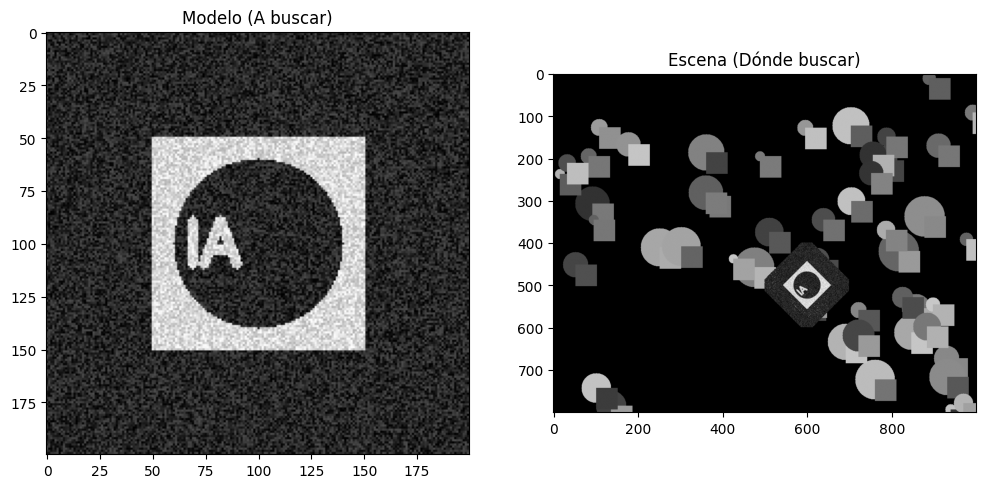

In [140]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def mostrar(img, titulo="Imagen"):
    plt.figure(figsize=(10,6))
    if len(img.shape) == 3:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(img, cmap='gray')
    plt.title(titulo)
    plt.axis('off')
    plt.show()

# 1. Crear el "Modelo" (Logo)
modelo = np.zeros((200, 200), dtype=np.uint8)
cv2.rectangle(modelo, (50, 50), (150, 150), 255, -1)
cv2.circle(modelo, (100, 100), 40, 0, -1)
cv2.putText(modelo, "IA", (65, 110), cv2.FONT_HERSHEY_SIMPLEX, 1, 255, 3)
# Añadir ruido al modelo (textura)
ruido = np.random.randint(0, 255, (200, 200), dtype=np.uint8)
modelo = cv2.addWeighted(modelo, 0.7, ruido, 0.3, 0)

# 2. Crear la "Escena" (Fondo grande con distracciones)
escena = np.zeros((800, 1000), dtype=np.uint8)
# Llenar de ruido y formas aleatorias
for _ in range(50):
    x, y = np.random.randint(0, 1000), np.random.randint(0, 800)
    cv2.circle(escena, (x, y), np.random.randint(10, 50), np.random.randint(50, 200), -1)
    cv2.rectangle(escena, (x, y), (x+50, y+50), np.random.randint(50, 200), -1)

# 3. Insertar el modelo transformado en la escena
# Rotar y escalar
M = cv2.getRotationMatrix2D((100, 100), 45, 0.8) # Rotado 45 grados, escala 0.8
modelo_trans = cv2.warpAffine(modelo, M, (200, 200))

# Pegar en la escena (posición 400, 500)
h, w = modelo_trans.shape
roi = escena[400:400+h, 500:500+w]
mask = (modelo_trans > 10)
escena[400:400+h, 500:500+w][mask] = modelo_trans[mask]

cv2.imwrite("modelo.png", modelo)
cv2.imwrite("escena.png", escena)

print("Imágenes generadas: 'modelo.png' y 'escena.png'.")
fig, ax = plt.subplots(1,2, figsize=(12,6))
ax[0].imshow(modelo, cmap='gray'); ax[0].set_title("Modelo (A buscar)")
ax[1].imshow(escena, cmap='gray'); ax[1].set_title("Escena (Dónde buscar)")
plt.show()

---

## BLOQUE 1: Conceptos Básicos (Guiados)
Entenderemos el flujo básico: Detectar -> Describir -> Emparejar.

### Ejercicio 1: Carga y Preparación
Cargamos las imágenes. Es vital trabajar en escala de grises para los descriptores.

In [141]:
img_modelo = cv2.imread('modelo.png', 0) # El 0 carga directamente en gris
img_escena = cv2.imread('escena.png', 0)

if img_modelo is None or img_escena is None:
    print("Error cargando imágenes. Ejecuta el Paso 0.")
else:
    print(f"Modelo: {img_modelo.shape}, Escena: {img_escena.shape}")

Modelo: (200, 200), Escena: (800, 1000)


### Ejercicio 2: El Ojo de la IA (Detector ORB)
Vamos a encontrar los **Keypoints** (puntos de interés) y sus **Descriptores** (DNI numérico).

Puntos en el modelo: 564
Puntos en la escena: 1000


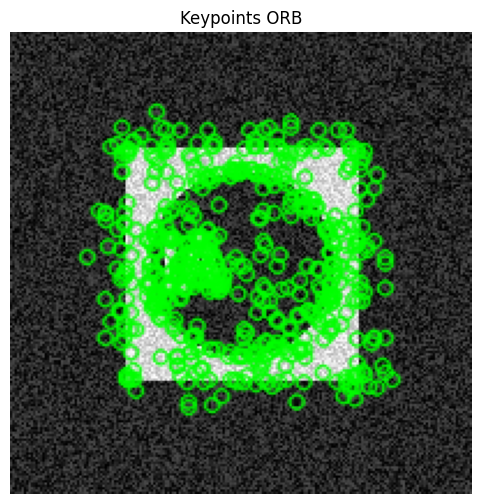

In [142]:
# 1. Iniciar el detector ORB (límite de 1000 puntos para no saturar)
orb = cv2.ORB_create(nfeatures=1000)

# 2. Detectar y Computar
# kp = Keypoints (coordenadas)
# des = Descriptores (arrays numéricos que describen el punto)
kp_modelo, des_modelo = orb.detectAndCompute(img_modelo, None)
kp_escena, des_escena = orb.detectAndCompute(img_escena, None)

print(f"Puntos en el modelo: {len(kp_modelo)}")
print(f"Puntos en la escena: {len(kp_escena)}")

# Visualicemos qué está viendo la máquina en el modelo
img_kp = cv2.drawKeypoints(img_modelo, kp_modelo, None, color=(0,255,0), flags=0)
mostrar(img_kp, "Keypoints ORB")

### Ejercicio 3: Fuerza Bruta (BFMatcher)
Vamos a comparar cada punto del modelo con TODOS los puntos de la escena.
Usaremos `NORM_HAMMING` porque ORB es binario.

Hemos encontrado 156 coincidencias.


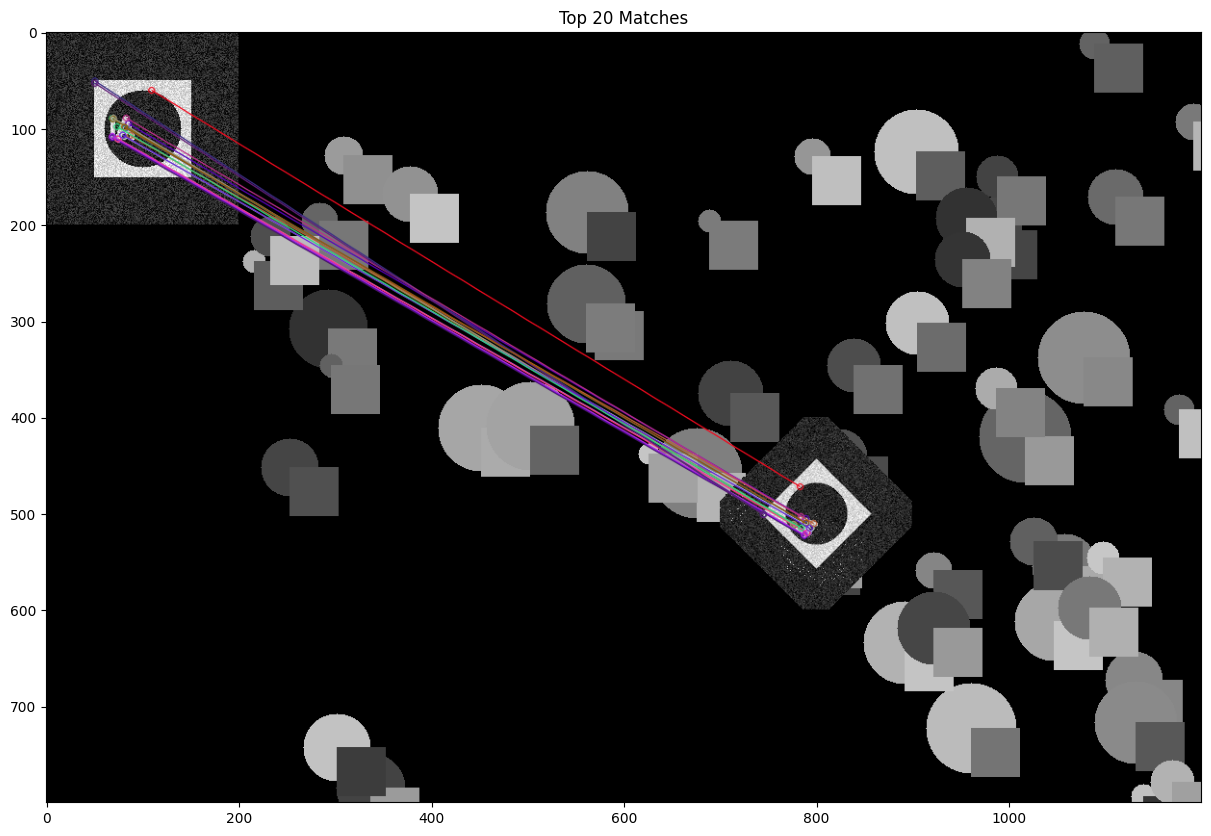

In [143]:
# 1. Crear el Matcher
# crossCheck=True asegura que el punto A encaje con el B, y el B con el A (doble verificación)
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

# 2. Realizar el emparejamiento
matches = bf.match(des_modelo, des_escena)

# 3. Ordenarlos por distancia (los más parecidos primero)
matches = sorted(matches, key=lambda x: x.distance)

print(f"Hemos encontrado {len(matches)} coincidencias.")

# 4. Dibujar los 20 mejores
img_matches = cv2.drawMatches(img_modelo, kp_modelo, img_escena, kp_escena, matches[:20], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

plt.figure(figsize=(15,10))
plt.imshow(img_matches)
plt.title("Top 20 Matches")
plt.show()

---

## BLOQUE 2: Refinamiento (A rellenar)
Las líneas de colores son bonitas, pero nosotros queremos encontrar el objeto y dibujarle una caja alrededor. Para eso necesitamos **Homografía**.

### Ejercicio 4: Extracción de Coordenadas
La variable `matches` tiene objetos `DMatch`. Necesitamos extraer las coordenadas $(x, y)$ de los puntos que coinciden para poder calcular la geometría.

**Tu misión:** Crea dos listas `src_pts` (puntos del modelo) y `dst_pts` (puntos en la escena).

In [144]:
# Nos quedamos solo con el Top 50 de matches para evitar ruido
good_matches = matches[:50]

src_pts = np.float32([ kp_modelo[m.queryIdx].pt for m in good_matches ]).reshape(-1, 1, 2)
dst_pts = np.float32([ kp_escena[m.trainIdx].pt for m in good_matches ]).reshape(-1, 1, 2)

print(f"Forma de src_pts: {src_pts.shape}") # Debería ser (50, 1, 2)

Forma de src_pts: (50, 1, 2)


### Ejercicio 5: La Matriz de Homografía
La homografía es una matriz $3x3$ que transforma la perspectiva de una imagen a otra. Es la magia matemática que nos dice cómo se ha rotado y deformado el objeto.

**Tu misión:** Usa `cv2.findHomography` para calcular la matriz `M`.

In [145]:
M, _ = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 0)

print("Matriz de Homografía:\n", M)

Matriz de Homografía:
 [[ 1.17212507e+00  8.23383585e-02  4.86097097e+02]
 [-5.34620176e-02  1.49257532e-01  4.99827036e+02]
 [ 1.01095905e-03 -8.20603283e-04  1.00000000e+00]]


### Ejercicio 6: Dibujando la Caja (Perspectiva)
Ahora que tenemos `M`, podemos coger las esquinas del modelo original y "proyectarlas" sobre la escena para ver dónde caen.

**Tu misión:** Completa la función `perspectiveTransform`.

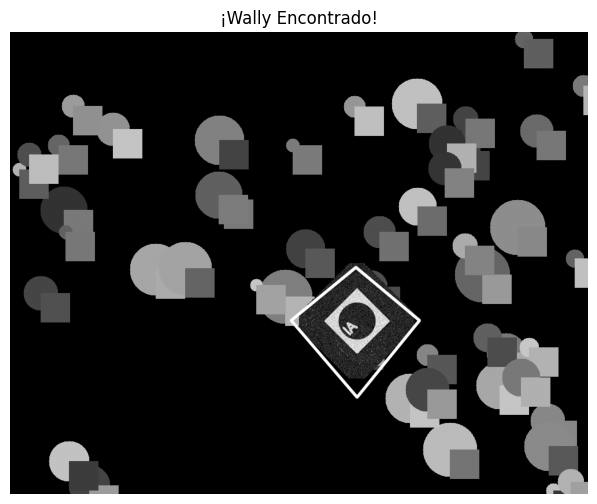

In [146]:
# 1. Definimos las esquinas del modelo original (h, w)
h, w = img_modelo.shape
pts = np.float32([ [0,0], [0,h-1], [w-1,h-1], [w-1,0] ]).reshape(-1,1,2)

# 2. Transformamos las esquinas usando la matriz M
dst = cv2.perspectiveTransform(pts, M)

# 3. Dibujamos la caja en la imagen de la escena
img_final = cv2.polylines(img_escena.copy(), [np.int32(dst)], True, 255, 3, cv2.LINE_AA)

mostrar(img_final, "¡Wally Encontrado!")

---

## BLOQUE 3: Retos
Demuestra que dominas la técnica.

### Ejercicio 7: KNN Matching (K-Nearest Neighbors)
En lugar de `bf.match` (que da 1 resultado), usa `bf.knnMatch` con `k=2`. Esto te dará los 2 mejores candidatos para cada punto.

**Reto:** Implementa el **Lowe's Ratio Test**. Un match es bueno solo si la distancia del primero (`m`) es menor que el 75% de la distancia del segundo (`n`).
Formula: `if m.distance < 0.75 * n.distance:`

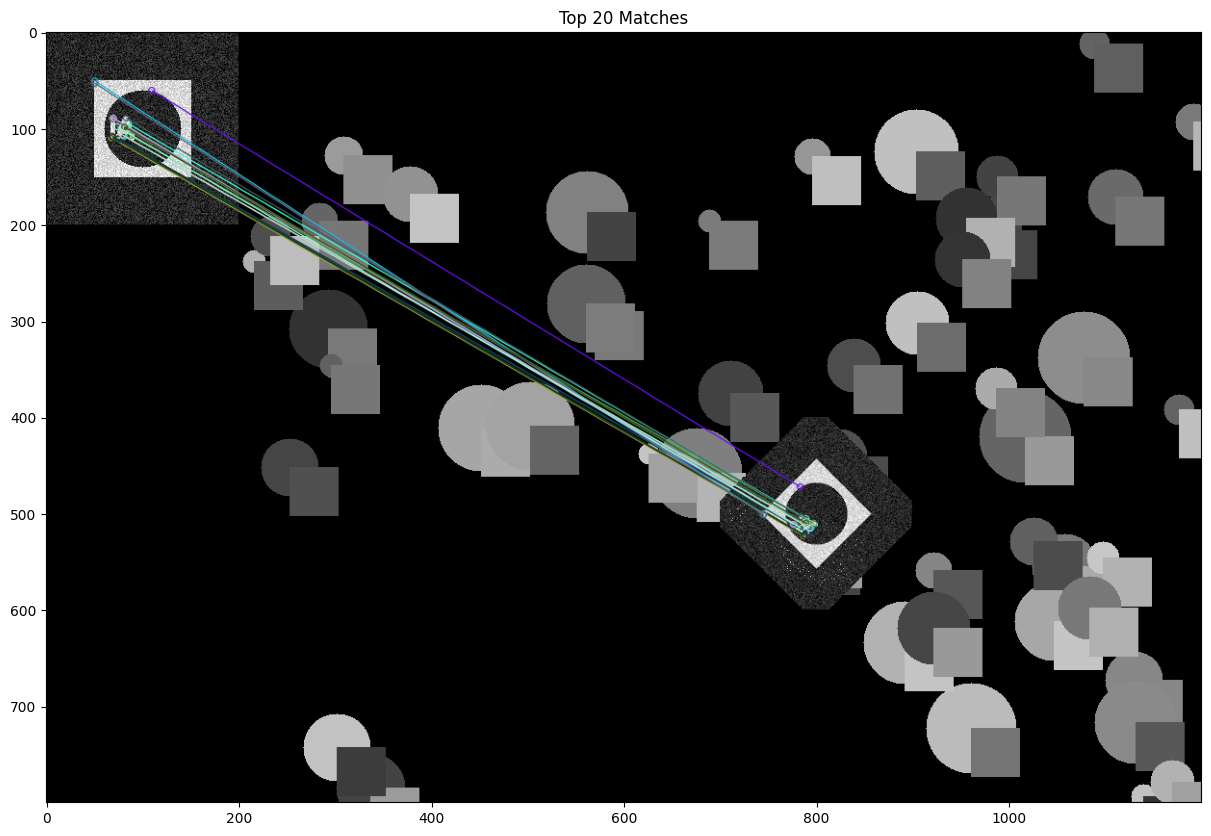

In [147]:
bf_knn = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)
knn_matches = bf_knn.knnMatch(des_modelo, des_escena, k = 2)
knn_good_matches = []
for m, n in knn_matches:
    if m.distance < 0.75 * n.distance:
        knn_good_matches.append(m)

img_knn_matches = cv2.drawMatches(img_modelo, kp_modelo, img_escena, kp_escena, matches[:20], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

plt.figure(figsize=(15,10))
plt.imshow(img_knn_matches)
plt.title("Top 20 Matches")
plt.show()

### Ejercicio 8: Enderezar el objeto (Un-Warp)
Ya sabes dónde está el objeto en la escena (está rotado). Usa `cv2.warpPerspective` y la inversa de la matriz o los puntos destino para recortar el objeto de la escena y mostrarlo "plano", como si lo miraras de frente.

*Pista: Quieres transformar la región detectada en la escena a un cuadrado de 200x200.*

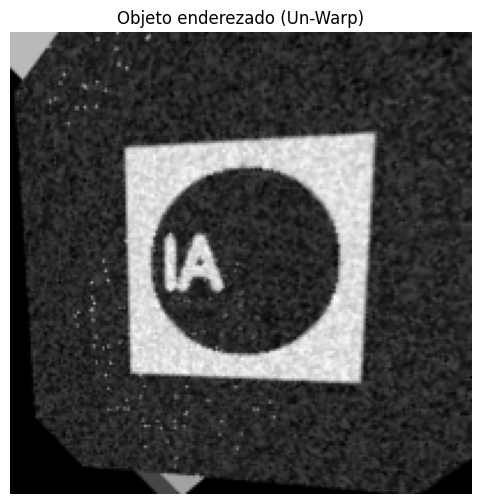

In [148]:
objeto_plano = cv2.warpPerspective(img_escena, np.linalg.inv(M), (200, 200))
mostrar(objeto_plano, "Objeto enderezado (Un-Warp)")

### Ejercicio 9: El impostor
¿Qué pasa si buscas el modelo en una imagen que NO lo contiene? 
Crea una imagen vacía (ruido), intenta buscar el modelo y cuenta cuántos `good_matches` salen.
Establece un umbral: "Si hay menos de X matches, imprime: Objeto no encontrado".

Hemos encontrado 47 coincidencias.


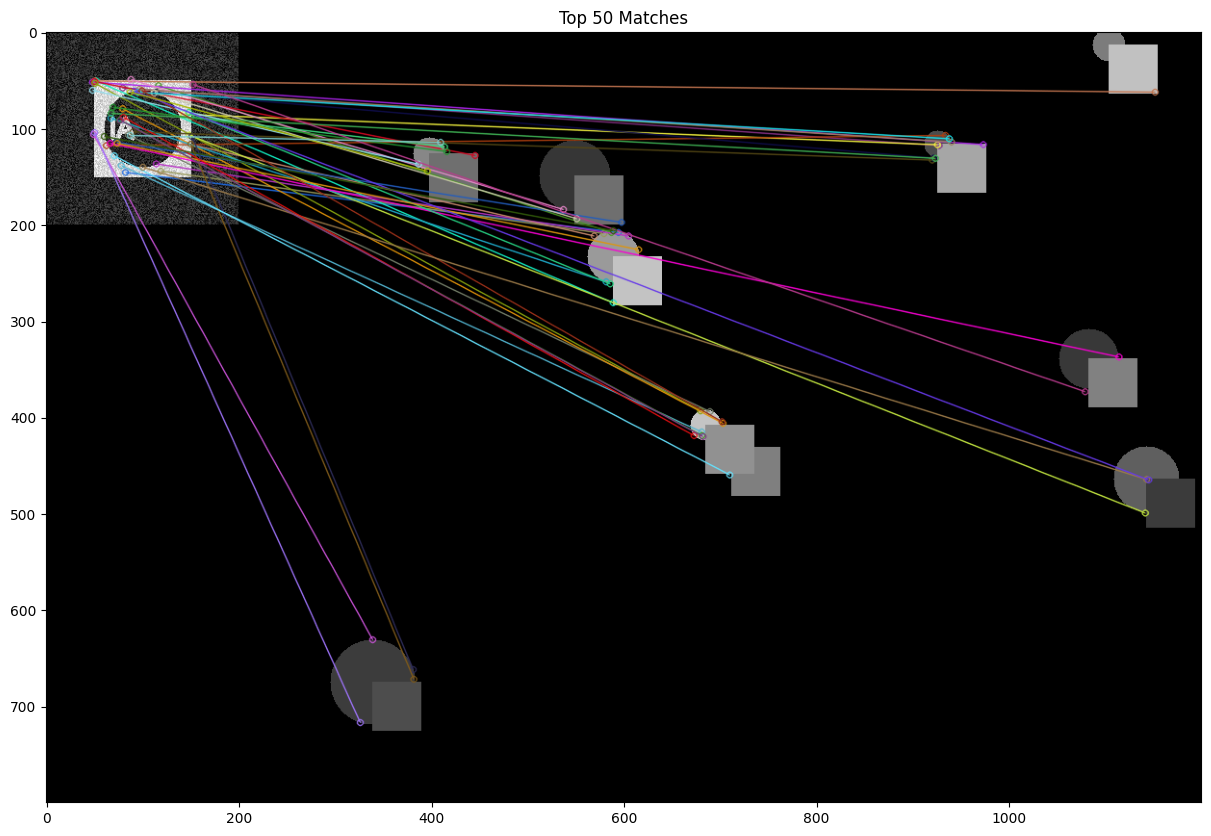

In [149]:
escena_vacia = np.zeros((800, 1000), dtype=np.uint8)
for _ in range(10):
    x, y = np.random.randint(0, 1000), np.random.randint(0, 800)
    cv2.circle(escena_vacia, (x, y), np.random.randint(10, 50), np.random.randint(50, 200), -1)
    cv2.rectangle(escena_vacia, (x, y), (x+50, y+50), np.random.randint(50, 200), -1)
kp_escena_vacia, des_escena_vacia = orb.detectAndCompute(escena_vacia, None)

bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

matches_impostor = bf.match(des_modelo, des_escena_vacia)

matches_impostor = sorted(matches_impostor, key=lambda x: x.distance)

good_matches = matches_impostor[:50]

print(f"Hemos encontrado {len(good_matches)} coincidencias.")

if good_matches.__len__() < 20:
    print("Objeto no encontrado")
else:
    img_matches_impostor = cv2.drawMatches(img_modelo, kp_modelo, escena_vacia, kp_escena_vacia, good_matches, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

    plt.figure(figsize=(15,10))
    plt.imshow(img_matches_impostor)
    plt.title("Top 50 Matches")
    plt.show()

### Ejercicio 10: Función Reutilizable `encontrar_objeto`
Empaqueta todo lo aprendido en una función limpia:
```python
def encontrar_objeto(img_objeto, img_escena, min_match=10):
    # Retorna la imagen con el recuadro dibujado o None si no lo encuentra
```
Prueba tu función.

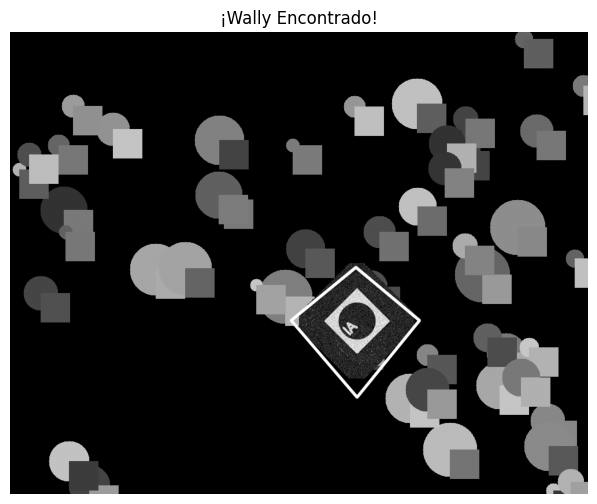

In [150]:
def encontrar_objeto(img_objeto, img_escena, min_match=10):
    # Iniciar el detector ORB (límite de 1000 puntos para no saturar)
    orb = cv2.ORB_create(nfeatures=1000)

    # Detectar y Computar
    # kp = Keypoints (coordenadas)
    # des = Descriptores (arrays numéricos que describen el punto)
    kp_modelo, des_modelo = orb.detectAndCompute(img_objeto, None)
    kp_escena, des_escena = orb.detectAndCompute(img_escena, None)

    # Crear el Matcher
    # crossCheck=True asegura que el punto A encaje con el B, y el B con el A (doble verificación)
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

    # Realizar el emparejamiento
    matches = bf.match(des_modelo, des_escena)

    # Ordenarlos por distancia (los más parecidos primero)
    matches = sorted(matches, key=lambda x: x.distance)

    # Nos quedamos solo con el Top 50 de matches para evitar ruido
    good_matches = matches[:50]

    if good_matches.__len__() < min_match:
        print("Objeto no encontrado")
    else:
        # Extraemos los puntos x e y de cada match
        src_pts = np.float32([ kp_modelo[m.queryIdx].pt for m in good_matches ]).reshape(-1, 1, 2)
        dst_pts = np.float32([ kp_escena[m.trainIdx].pt for m in good_matches ]).reshape(-1, 1, 2)

        # Creamos la matriz de homografía
        M, _ = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 0)

        # Definimos las esquinas del modelo original (h, w)
        h, w = img_objeto.shape
        pts = np.float32([ [0,0], [0,h-1], [w-1,h-1], [w-1,0] ]).reshape(-1,1,2)

        # Transformamos las esquinas usando la matriz M
        dst = cv2.perspectiveTransform(pts, M)

        # Dibujamos la caja en la imagen de la escena
        img_final = cv2.polylines(img_escena.copy(), [np.int32(dst)], True, 255, 3, cv2.LINE_AA)

        mostrar(img_final, "¡Wally Encontrado!")
        
encontrar_objeto(img_modelo, img_escena)
    